# Project 1 — Sine Wave Forecasting (the "hello world" of RNNs)

**Goal:** Predict the *next* value of a noisy sine wave from the previous `N` steps.

### Why this project?
There is no data cleaning here — we *generate* the data with `np.sin`. That means you can spend 100% of your energy on the only new thing: **the sequence dimension**. If your model can't fit a sine wave, the bug is in your plumbing, not the data.

### What you will figure out
1. The **sliding-window** trick: turning a 1D signal into `(samples, seq_len, 1)` supervised pairs.
2. How `nn.RNN` / `nn.LSTM` return `output` vs `(h_n, c_n)` — this trips *everyone* up.
3. Taking only the **last** timestep's hidden state and feeding it to a `Linear` head.

### How to use this notebook
Cells marked with **`# 🛠️ TODO`** are for *you* to implement. Everything else (data, plotting, training loop skeleton) is provided so you can focus on the RNN. When you get stuck on a shape or the forward pass, that's the moment to learn — show me the error and we debug it together.

---

## Step 0 — Imports & device
*(provided)*

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Step 1 — Generate the data
*(provided)*

We create a long, slightly noisy sine wave. Think of it as one continuous time series.

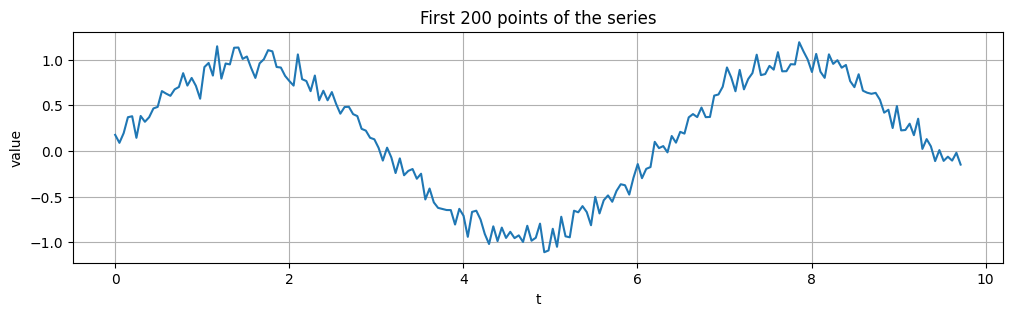

In [2]:
N_POINTS = 2050
# I take two sets of data. One has shape (2050, 1), and other has (2000, 1)
t2050 = np.linspace(0, 100, N_POINTS)
series2050 = np.sin(t2050) + 0.1 * np.random.randn(N_POINTS)   # sine + a little noise
t = t2050[:2000]
series2050 = series2050.astype(np.float32)
series = series2050[:2000]

plt.figure(figsize=(12, 3))
plt.plot(t[:200], series[:200])
plt.title("First 200 points of the series")
plt.xlabel("t"); plt.ylabel("value"); plt.grid(True)
plt.show()

## Step 2 — The sliding-window trick
*(provided — but read it carefully, this is the heart of sequence data prep)*

A supervised example is: *given the previous `seq_len` values, predict the next one.*

So for `seq_len = 3` and series `[a, b, c, d, e]` we get:

| X (input window)   | y (target) |
|--------------------|------------|
| `[a, b, c]`        | `d`        |
| `[b, c, d]`        | `e`        |

The final `X` shape must be **`(n_samples, seq_len, n_features)`** — PyTorch RNNs expect `n_features` as the last dim (here it's `1`, a single value per timestep).

In [ ]:
def make_windows(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i : i + seq_len])   # the window
        y.append(series[i + seq_len])       # the next value
    X = np.array(X)[..., np.newaxis]        # -> (n_samples, seq_len, 1)
    y = np.array(y)[..., np.newaxis]        # -> (n_samples, 1)
    return X.astype(np.float32), y.astype(np.float32)

SEQ_LEN = 20
X, y = make_windows(series, SEQ_LEN)
print("X shape:", X.shape, "   y shape:", y.shape)
# Sanity check: X should be (n_samples, SEQ_LEN, 1)

X has shape 1980 before adding new axis
X shape: (1980, 20, 1)    y shape: (1980, 1)


## Step 3 — Train / test split (NO shuffling!)
*(provided)*

For time series we split by **time**: the model trains on the past and is tested on the future. Shuffling would leak the future into training.

In [6]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = torch.from_numpy(X_train).to(device)
y_train = torch.from_numpy(y_train).to(device)
X_test  = torch.from_numpy(X_test).to(device)
y_test  = torch.from_numpy(y_test).to(device)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: torch.Size([1584, 20, 1]) torch.Size([1584, 1])
Test : torch.Size([396, 20, 1]) torch.Size([396, 1])


## Step 4 — 🛠️ BUILD THE MODEL (your job!)

Implement an RNN that maps a window `(batch, seq_len, 1)` to a single prediction `(batch, 1)`.

### Hints
- Use `nn.RNN(input_size, hidden_size, batch_first=True)`. `batch_first=True` means it expects `(batch, seq_len, features)` — matching our data.
- `nn.RNN` returns **two** things:
  ```python
  out, h_n = self.rnn(x)
  # out  -> (batch, seq_len, hidden_size)   # hidden state at EVERY timestep
  # h_n  -> (num_layers, batch, hidden_size) # hidden state at the LAST timestep
  ```
- For one-step forecasting you only need the **last** timestep. Two equivalent ways:
  - `out[:, -1, :]`  (last timestep from `out`)
  - `h_n[-1]`        (last layer's final hidden state)
- Feed that `(batch, hidden_size)` tensor into a `nn.Linear(hidden_size, 1)` to get your prediction.

Fill in the `TODO`s below.

In [7]:
class RNNForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        # 🛠️ TODO: create self.rnn = nn.RNN(...)  with batch_first=True
        # 🛠️ TODO: create self.fc  = nn.Linear(...) mapping hidden_size -> 1
        # raise NotImplementedError("Build __init__")
    def forward(self, x):
        rnn_out, hidden_state = self.rnn(x)
        out = self.fc(hidden_state[-1])
        # x: (batch, seq_len, input_size)
        # 🛠️ TODO: pass x through self.rnn -> get out, h_n
        # 🛠️ TODO: grab the last timestep's hidden state
        # 🛠️ TODO: pass it through self.fc and return the (batch, 1) prediction
        # raise NotImplementedError("Build forward")
        return out


# 🛠️ TODO: instantiate the model and move it to `device`
model = RNNForecaster().to(device)
print(model)

RNNForecaster(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


### Quick shape check (run after building the model)
*(provided — this catches most bugs before training)*

In [8]:
with torch.no_grad():
    dummy = X_train[:5]                 # (5, SEQ_LEN, 1)
    pred = model(dummy)                 # should be (5, 1)
    print("input :", dummy.shape)
    print("output:", pred.shape)
    assert pred.shape == (5, 1), "Output shape is wrong — revisit forward()"
    print("✅ shapes look correct")

input : torch.Size([5, 20, 1])
output: torch.Size([5, 1])
✅ shapes look correct


## Step 5 — 🛠️ Training loop (mostly your job)

The skeleton is provided. Fill in the 5 canonical steps of a PyTorch training iteration.

### The 5 steps (you already know these from CNNs!)
1. `optimizer.zero_grad()`
2. forward: `pred = model(X_train)`
3. `loss = criterion(pred, y_train)`
4. `loss.backward()`
5. `optimizer.step()`

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 200
losses = []
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train)
    loss = criterion(pred, y_train)
    loss.backward()
    optimizer.step()

    # 🛠️ TODO: implement the 5 steps here
    # (for this small dataset we train on the full batch each epoch)
    # raise NotImplementedError("Implement the training step")

    losses.append(loss.item()) # Mean over batch is default setting
    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch+1:3d} | loss {loss.item():.5f}")

epoch  20 | loss 0.01681
epoch  40 | loss 0.01825
epoch  60 | loss 0.01578
epoch  80 | loss 0.01510
epoch 100 | loss 0.01410
epoch 120 | loss 0.01360
epoch 140 | loss 0.01320
epoch 160 | loss 0.01274
epoch 180 | loss 0.01236
epoch 200 | loss 0.01198


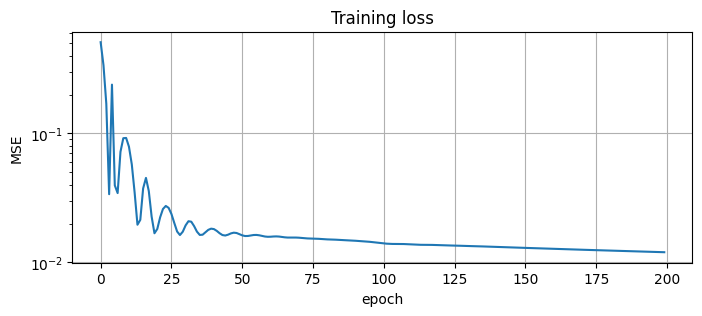

In [10]:
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training loss"); plt.xlabel("epoch"); plt.ylabel("MSE")
plt.yscale("log"); plt.grid(True)
plt.show()

## Step 6 — Evaluate & plot predictions
*(provided)*

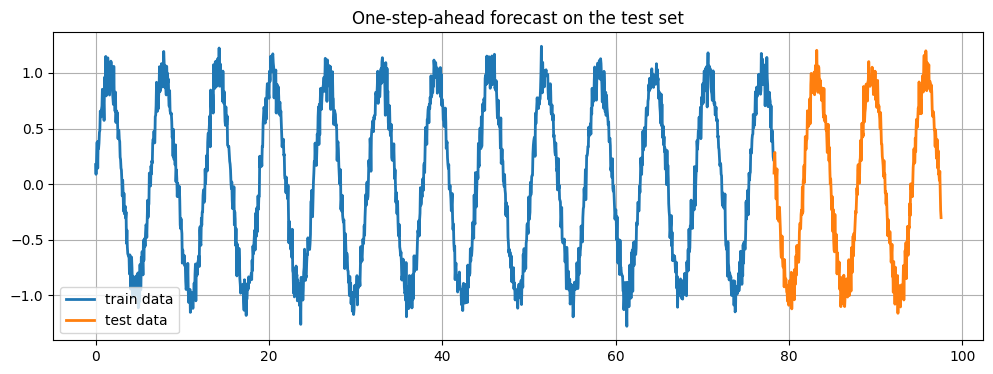

Test MSE: 0.01216


In [26]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test).cpu().numpy().ravel()

y_test_np = y_test.cpu().numpy().ravel()

plt.figure(figsize=(12, 4))
plt.plot(t[:split+ SEQ_LEN], series[:split+SEQ_LEN], label='train data', linewidth=2)
plt.plot(t[split + SEQ_LEN:] ,series[split + SEQ_LEN:], label='test data', linewidth=2)

# Predictions times: One step prediction and their true labels
prediction_times = t[split + SEQ_LEN : 2000]
# plt.plot( prediction_times, test_pred, label='Network Output', linestyle = "--")
# plt.plot(prediction_times, y_test_np, label='true test labels', linestyle= "--")
# plt.plot(prediction_times, y_test_np, label="true test labels", alpha=0.7)
# plt.plot(y_test_np, label="true", linewidth=2)
# plt.plot(test_pred, label="predicted", linestyle="--")
plt.title("One-step-ahead forecast on the test set")
plt.legend(); plt.grid(True)
plt.show()

test_mse = np.mean((test_pred - y_test_np) ** 2)
print(f"Test MSE: {test_mse:.5f}")

In [19]:
t.shape, X.shape, test_pred.shape

((2000,), (1980, 20, 1), (396,))

In [27]:
# Recursive multi-step forecast: feed the model's own predictions back in.
model.eval()
H = 50  # forecast horizon

# seed with the last SEQ_LEN KNOWN points (never the future we want to predict)
window = torch.from_numpy(series2050[2000 - SEQ_LEN : 2000, None]).to(device)  # (SEQ_LEN, 1)

preds = []
with torch.no_grad():
    for _ in range(H):
        yhat = model(window.unsqueeze(0))                     # (1, 1)
        preds.append(yhat.item())
        window = torch.cat([window[1:], yhat.view(1, 1)], 0)  # slide: drop oldest, append own prediction

preds = np.array(preds)
print("forecast shape:", preds.shape)

forecast shape: (50,)


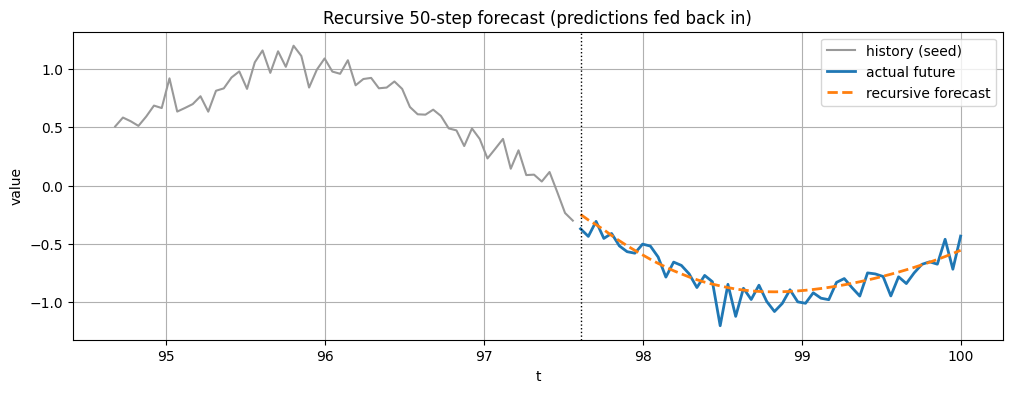

Recursive 50-step MSE: 0.00999   (compare to 1-step Test MSE ~0.012)


In [28]:
# Compare the recursive forecast against the real future points series2050[2000:2050]
t_future = t2050[2000:2000 + H]
actual_future = series2050[2000:2000 + H]

# a bit of recent history for context
hist = 60
t_hist = t2050[2000 - hist : 2000]
series_hist = series2050[2000 - hist : 2000]

plt.figure(figsize=(12, 4))
plt.plot(t_hist, series_hist, color="0.6", label="history (seed)")
plt.plot(t_future, actual_future, linewidth=2, label="actual future")
plt.plot(t_future, preds, "--", linewidth=2, label="recursive forecast")
plt.axvline(t2050[2000], color="k", linestyle=":", linewidth=1)  # forecast start
plt.title(f"Recursive {H}-step forecast (predictions fed back in)")
plt.xlabel("t"); plt.ylabel("value")
plt.legend(); plt.grid(True)
plt.show()

forecast_mse = np.mean((preds - actual_future) ** 2)
print(f"Recursive {H}-step MSE: {forecast_mse:.5f}   (compare to 1-step Test MSE ~0.012)")

Test MSE: 0.01183 for hidden size of 32  

Test MSE: 0.01624 for hidden size of 8  

Test MSE: 0.01277 for hidden size of 64

---
Test MSE: 0.01711 for sequence length 5, Training loss is more wiglly i.e. up-down  

Test MSE: 0.02289 for sequence length 50, Training loss comes down faster way-less wiglliness 

---
With `nn.LSTM` the only change is that the output of the first layer is also the memory layer `c_n`: ``out, (h_n,c_n)``.


## Step 7 — Reflect (answer these in your head or in a cell)

1. **Shapes:** Why does `nn.RNN` want `(batch, seq_len, features)`? What did `batch_first=True` change? 
> `batch_first=True` allows `nn.RNN` to take `batch` as the first input dimension
2. **`out` vs `h_n`:** You used the last timestep. What information is in `out[:, :-1, :]` that you *threw away*? When might you need it? 
> Basically `out` at each step contains the prediction at the next time step. However, we are interested in encoding process i.e. `h_n`
3. **Experiments to try:**
   - Change `hidden_size` (e.g., 8 vs 64). What happens to the fit? > fit does not improve 
   - Change `SEQ_LEN` (e.g., 5 vs 50). Does a longer window help?
   - Swap `nn.RNN` → `nn.LSTM`. ⚠️ Careful: `nn.LSTM` returns `out, (h_n, c_n)` — a **tuple** for the state. Adjust your `forward`.
4. **Stretch:** Do *recursive* multi-step forecasting — feed your own prediction back in to forecast 50 steps into the future. How fast does error accumulate?

---
When you've filled in the TODOs and run it, send me your result (or any error) and we'll debug + discuss before moving to **Project 2**.

### Summary
1. The network output accuracy is bounded by the data noise floor. In out case: $\sigma^2 = 0.01$. Notice that the notwork hits noise floor with right parameters.
2. In an RNN, the `SEQ_LEN` is actually the depth of the network. Below is the mental model for RNN.
````
step 1:  x₁ ─┐
             ├─► h₁  
       h₀ ──┘  


step 2:  x₂ ─┐
             ├─► h₂
       h₁ ──┘  


   ...        (20 steps total, one per input value)

step 20: x₂₀ ─┐
              ├─► h₂₀ ──► fc ──► ŷ   ◄── the ONE prediction
      h₁₉ ──┘  
````
3. **Vanishing Gradient Problem**: $|| \frac{\partial L}{\partial h_k} || \propto ||\prod_{t=k+1}^T \frac{\partial h_t}{\partial h_{t-1}} || \sim \lambda^T$

4. `out` contains all the hidden states, one per timestep $\rightarrow$ `[h_1, h_2, \dots, h_20]`
5. `h_n` contains only the last hidden state $\rightarrow$ `h_20`
6. `hidden_size = width of the network`
7. `SEQ_LEN = depth of the network`

### To Reflect further
1. Get over backprop derivation in context of RNN once again. what is `\lambda` in case of `tanh` ..why `diag(tanh'(.))W_h`
2. Come back again to understand recursive forecasting: It shows the compounding effect of the error accumulation because we are doing prediction based on last prediction continuously.
3. ...
4. ...